# 11 Confidence Intervals

In Chapter 10, we learned that a sample statistic changes from sample to sample.

Now we ask:

> **How can we express the uncertainty around a sample estimate?**

A **confidence interval** gives a range of plausible values for a population parameter.

This chapter focuses on confidence intervals for a **population mean**.

## Learning Objectives

After completing this chapter, you will be able to:

- distinguish a point estimate from an interval estimate;
- understand the structure of a confidence interval;
- calculate a standard error;
- understand critical values and margin of error;
- construct a confidence interval for a population mean;
- distinguish the Z-based and t-based approaches;
- correctly interpret a 95% confidence interval;
- understand how confidence level and sample size affect interval width;
- verify confidence-interval coverage through repeated sampling.

## 1. From Point Estimate to Interval Estimate

Suppose we want to estimate the population mean $\mu$.

From a random sample, we calculate:

$$
\bar{x}
$$

This is a **point estimate**.

But another random sample would usually give a slightly different value.

Instead of reporting only one number, we can report an interval:

$$
\text{Lower Bound}
\leq
\mu
\leq
\text{Upper Bound}
$$

This is the basic idea of a **confidence interval**.

## 2. General Structure

A confidence interval usually has the form:

$$
\text{Estimate}
\pm
\text{Margin of Error}
$$

For a mean:

$$
\bar{x}
\pm
(\text{Critical Value})\times(\text{Standard Error})
$$

So the main ingredients are:

1. a point estimate;
2. a standard error;
3. a critical value;
4. a margin of error.

## 3. Dataset

`11_confidence_intervals.csv` contains a **synthetic finite population of 2,000 fictional employees**.

Columns:

- `employee_id`
- `department`
- `commute_time_minutes`

The dataset is fictional and exists only for education.

As in Chapter 10, we deliberately know the entire synthetic population. This lets us check whether confidence intervals produced from random samples contain the true population mean.

In real inference, the true population mean is usually unknown.

In [1]:
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from scipy.stats import norm, t

cwd = Path.cwd().resolve()
root = next(
    (p for p in [cwd, *cwd.parents] if (p / "data").is_dir()),
    None,
)

if root is None:
    raise FileNotFoundError("Could not find project root containing data/.")

population = pd.read_csv(root / "data" / "11_confidence_intervals.csv")
population.head()

,employee_id,department,commute_time_minutes
0,Employee_0001,Department_C,28.7
1,Employee_0002,Department_B,55.0
2,Employee_0003,Department_D,33.8
3,Employee_0004,Department_C,36.8
4,Employee_0005,Department_A,35.6


In [2]:
print(f"Population size: {len(population)}")

population_mean = population["commute_time_minutes"].mean()
population_std = population["commute_time_minutes"].std(ddof=0)

print(f"True population mean (μ): {population_mean:.2f} minutes")
print(f"Population SD (σ):        {population_std:.2f} minutes")

Population size: 2000
True population mean (μ): 43.50 minutes
Population SD (σ):        11.24 minutes


## 4. Draw a Random Sample

Suppose we observe only 50 employees.

From that sample we calculate:

- sample mean $\bar{x}$;
- sample standard deviation $s$;
- sample size $n$.

In [3]:
sample = population.sample(n=50, random_state=42)

x_bar = sample["commute_time_minutes"].mean()
s = sample["commute_time_minutes"].std(ddof=1)
n = len(sample)

print(f"Sample size (n): {n}")
print(f"Sample mean (x̄): {x_bar:.2f}")
print(f"Sample SD (s):    {s:.2f}")

Sample size (n): 50
Sample mean (x̄): 42.48
Sample SD (s):    10.50


## 5. Standard Error

From Chapter 10, the standard error of the sample mean is approximately:

$$
SE(\bar{X})=\frac{\sigma}{\sqrt{n}}
$$

But in real analysis, the population standard deviation $\sigma$ is usually unknown.

We therefore often estimate the standard error using the sample standard deviation:

$$
SE(\bar{X})
\approx
\frac{s}{\sqrt{n}}
$$

In [4]:
standard_error = s / np.sqrt(n)

print(f"Estimated standard error: {standard_error:.3f}")

Estimated standard error: 1.484


## 6. Confidence Level and Critical Value

A common choice is a **95% confidence level**.

If the population standard deviation is known and a Normal/Z framework is appropriate, the 95% critical value is approximately:

$$
z^*=1.96
$$

This produces:

$$
\bar{x}
\pm
1.96\times SE
$$

In [5]:
confidence_level = 0.95
alpha = 1 - confidence_level

z_critical = norm.ppf(1 - alpha / 2)

print(f"95% Z critical value: {z_critical:.4f}")

95% Z critical value: 1.9600


## 7. Z-based Confidence Interval

For teaching purposes, because our synthetic population is fully visible, we know $\sigma$.

The Z-based interval is:

$$
\bar{x}
\pm
z^*
\frac{\sigma}{\sqrt{n}}
$$

In [6]:
se_known_sigma = population_std / np.sqrt(n)
z_margin = z_critical * se_known_sigma

z_lower = x_bar - z_margin
z_upper = x_bar + z_margin

print(f"Z-based 95% CI: ({z_lower:.2f}, {z_upper:.2f})")

Z-based 95% CI: (39.36, 45.59)


## 8. t-based Confidence Interval

In most realistic situations, $\sigma$ is unknown.

When estimating a population mean using $s$, we commonly use the **t-distribution**.

$$
\bar{x}
\pm
t^*
\frac{s}{\sqrt{n}}
$$

The t-distribution depends on **degrees of freedom**:

$$
df=n-1
$$

In [7]:
dfree = n - 1
t_critical = t.ppf(1 - alpha / 2, df=dfree)

margin_of_error = t_critical * standard_error

lower = x_bar - margin_of_error
upper = x_bar + margin_of_error

print(f"Degrees of freedom: {dfree}")
print(f"t critical value:   {t_critical:.4f}")
print(f"Margin of error:    {margin_of_error:.2f}")
print(f"95% t-based CI:     ({lower:.2f}, {upper:.2f})")

Degrees of freedom: 49
t critical value:   2.0096
Margin of error:    2.98
95% t-based CI:     (39.49, 45.46)


## 9. Why Is t Different from Z?

The t-distribution resembles the Standard Normal Distribution but has heavier tails.

This reflects additional uncertainty because $\sigma$ is unknown and is estimated using $s$.

As the sample size increases, the t-distribution approaches the Standard Normal Distribution.

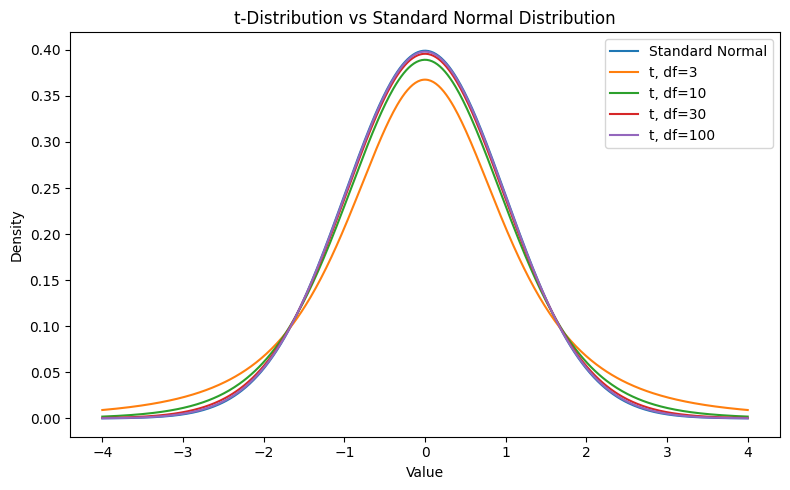

In [8]:
dfs = [3, 10, 30, 100]
x = np.linspace(-4, 4, 500)

plt.figure(figsize=(8, 5))

plt.plot(x, norm.pdf(x), label="Standard Normal")

for dfree in dfs:
    plt.plot(x, t.pdf(x, df=dfree), label=f"t, df={dfree}")

plt.title("t-Distribution vs Standard Normal Distribution")
plt.xlabel("Value")
plt.ylabel("Density")
plt.legend()
plt.tight_layout()
plt.show()

## 10. Correct Interpretation of a 95% Confidence Interval

A common but misleading statement is:

> “There is a 95% probability that the fixed population mean is inside this particular interval.”

In the standard frequentist interpretation, the population parameter $\mu$ is fixed.

The interval is random because it changes from sample to sample.

The correct long-run interpretation is:

> **If we repeatedly took samples and constructed intervals using the same 95% procedure, about 95% of those intervals would contain the true population mean.**

This repeated-sampling interpretation is fundamental.

## 11. Repeated Sampling Experiment

Because we know the true mean of our synthetic population, we can test the confidence-interval procedure.

We will:

1. draw many random samples;
2. construct a 95% t-based confidence interval for each sample;
3. check whether each interval contains the true population mean.

In [9]:
rng = np.random.default_rng(42)

n_repetitions = 1000
sample_size = 50
contains_true_mean = []

for _ in range(n_repetitions):
    values = rng.choice(
        population["commute_time_minutes"],
        size=sample_size,
        replace=False,
    )

    sample_mean = values.mean()
    sample_sd = values.std(ddof=1)
    se = sample_sd / np.sqrt(sample_size)

    critical = t.ppf(
        0.975,
        df=sample_size - 1,
    )

    lower_ci = sample_mean - critical * se
    upper_ci = sample_mean + critical * se

    contains_true_mean.append(
        lower_ci <= population_mean <= upper_ci
    )

coverage = np.mean(contains_true_mean)

print(f"Observed coverage: {coverage:.3%}")

Observed coverage: 96.600%


The observed percentage will usually be close to 95%, but it does not have to equal exactly 95% in a finite simulation.

That is the meaning of the **confidence level as a long-run success rate of the procedure**.

## 12. Visualizing Multiple Confidence Intervals

Let's construct 30 intervals and see which ones contain the true population mean.

In [10]:
rng = np.random.default_rng(7)

intervals = []

for i in range(30):
    values = rng.choice(
        population["commute_time_minutes"],
        size=50,
        replace=False,
    )

    mean_i = values.mean()
    sd_i = values.std(ddof=1)
    se_i = sd_i / np.sqrt(50)
    critical_i = t.ppf(0.975, df=49)

    low_i = mean_i - critical_i * se_i
    high_i = mean_i + critical_i * se_i

    intervals.append(
        (i + 1, mean_i, low_i, high_i,
         low_i <= population_mean <= high_i)
    )

interval_df = pd.DataFrame(
    intervals,
    columns=["sample", "mean", "lower", "upper", "contains_mu"],
)

interval_df.head()

,sample,mean,lower,upper,contains_mu
0,1,41.134,37.519533,44.748467,True
1,2,43.606,40.140147,47.071853,True
2,3,42.084,38.939239,45.228761,True
3,4,44.344,40.555211,48.132789,True
4,5,44.038,41.040923,47.035077,True


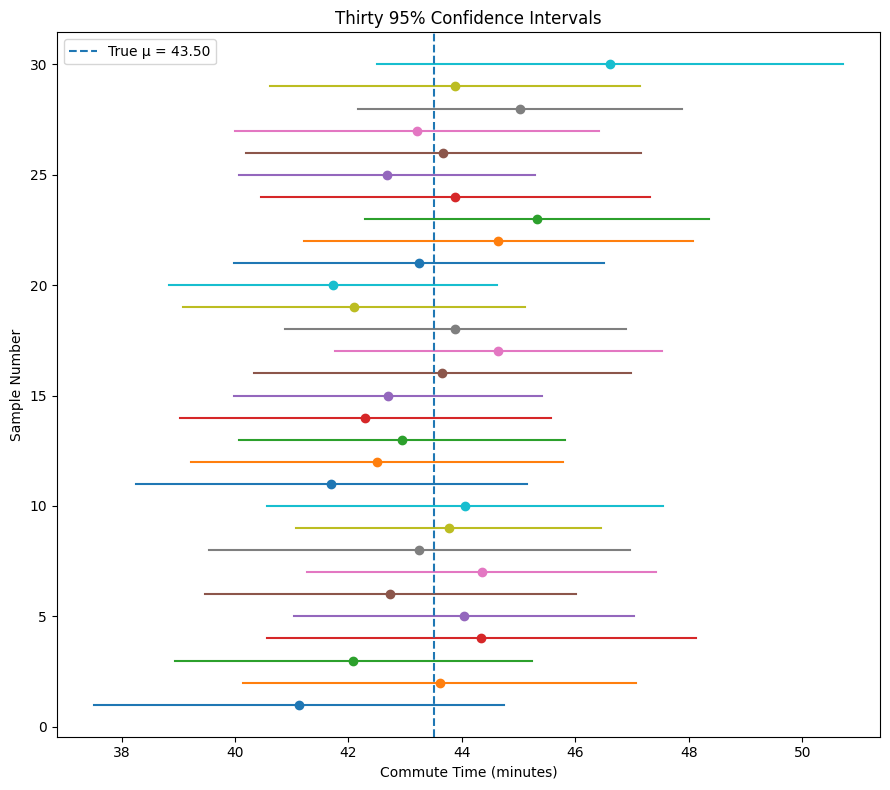

In [11]:
plt.figure(figsize=(9, 8))

for _, row in interval_df.iterrows():
    marker = "o" if row["contains_mu"] else "x"

    plt.plot(
        [row["lower"], row["upper"]],
        [row["sample"], row["sample"]],
    )
    plt.scatter(
        row["mean"],
        row["sample"],
        marker=marker,
    )

plt.axvline(
    population_mean,
    linestyle="--",
    label=f"True μ = {population_mean:.2f}",
)

plt.title("Thirty 95% Confidence Intervals")
plt.xlabel("Commute Time (minutes)")
plt.ylabel("Sample Number")
plt.legend()
plt.tight_layout()
plt.show()

## 13. Confidence Level and Interval Width

Higher confidence requires a wider interval.

For example:

$$
90\%,\quad95\%,\quad99\%
$$

have increasingly large critical values.

Holding the same sample fixed, let's compare them.

In [12]:
for confidence in [0.90, 0.95, 0.99]:
    alpha = 1 - confidence
    critical = t.ppf(
        1 - alpha / 2,
        df=n - 1,
    )

    margin = critical * standard_error

    print(
        f"{confidence:.0%} CI: "
        f"({x_bar - margin:.2f}, {x_bar + margin:.2f}) "
        f"| width={2 * margin:.2f}"
    )

90% CI: (39.99, 44.97) | width=4.98
95% CI: (39.49, 45.46) | width=5.97
99% CI: (38.50, 46.46) | width=7.96


The trade-off is:

> **Higher confidence → wider interval**

A wider interval is more likely to capture the population parameter, but it provides less precision.

## 14. Sample Size and Interval Width

Increasing sample size reduces:

$$
SE=\frac{s}{\sqrt{n}}
$$

Therefore, larger samples generally produce narrower confidence intervals.

Let's compare several sample sizes using the population standard deviation only to isolate the effect of $n$.

In [13]:
for sample_size in [20, 50, 100, 500]:
    se = population_std / np.sqrt(sample_size)
    margin = z_critical * se

    print(
        f"n={sample_size:3d} | "
        f"SE={se:.3f} | "
        f"Approx. 95% width={2 * margin:.2f}"
    )

n= 20 | SE=2.513 | Approx. 95% width=9.85
n= 50 | SE=1.589 | Approx. 95% width=6.23
n=100 | SE=1.124 | Approx. 95% width=4.40
n=500 | SE=0.503 | Approx. 95% width=1.97


The relationship is not linear because:

$$
SE\propto\frac{1}{\sqrt{n}}
$$

For example, roughly halving the standard error requires multiplying the sample size by about four.

## 15. Assumptions and Practical Caution

A confidence interval formula is not magic.

For a mean, we should think about:

- whether observations were sampled appropriately;
- independence or the sampling design;
- extreme outliers;
- sample size;
- whether the method's distributional assumptions or approximations are reasonable.

A mathematically narrow interval from biased data can still be misleading.

Confidence intervals quantify **sampling uncertainty under a model/procedure**. They do not automatically correct poor data collection.

## Important Distinctions

### Point Estimate vs Interval Estimate
$\bar{x}$ gives one estimate. A confidence interval adds a range that reflects uncertainty.

### Standard Deviation vs Standard Error
Standard deviation describes variability among individual observations. Standard error describes variability of a statistic across repeated samples.

### Z vs t
Z is natural when $\sigma$ is known under the corresponding Normal framework. t is commonly used for inference about a mean when $\sigma$ is unknown and estimated from the sample.

### Confidence Level vs Probability of the Fixed Parameter
A 95% confidence level describes the long-run coverage of the interval-building procedure, not a 95% probability assigned to a fixed $\mu$ after one frequentist interval has been calculated.

### Precision vs Confidence
Higher confidence widens the interval. Larger samples generally narrow it.

## Exercises

### Exercise 1
Draw a random sample of 30 employees and calculate a 95% t-based confidence interval for the population mean commute time.

### Exercise 2
Using the same sample, compare 90%, 95%, and 99% confidence intervals.

Which is widest, and why?

### Exercise 3
Compare confidence intervals using samples of:

$$
n=20,\quad50,\quad100,\quad200
$$

How does sample size affect interval width?

### Exercise 4
Repeat the confidence-interval procedure 5,000 times and calculate the observed coverage rate.

### Exercise 5
Explain in your own words why this statement is misleading in the frequentist framework:

> “There is a 95% probability that $\mu$ is inside this particular 95% confidence interval.”

### Exercise 6
Explain the difference between standard deviation and standard error.

### Exercise 7
A survey has an extremely narrow confidence interval but uses a strongly biased convenience sample.

Does the narrow interval guarantee an accurate estimate of the target population? Explain.

## Summary

A confidence interval combines:

$$
\text{Point Estimate}
+
\text{Sampling Uncertainty}
$$

Its general structure is:

$$
\text{Estimate}
\pm
\text{Critical Value}\times\text{Standard Error}
$$

You learned:

- point estimates and interval estimates;
- standard error;
- critical values;
- margin of error;
- Z-based and t-based confidence intervals;
- the correct repeated-sampling interpretation of 95% confidence;
- coverage;
- the effect of confidence level;
- the effect of sample size;
- important assumptions and limitations.

The key idea is:

> **A confidence interval does not eliminate uncertainty—it quantifies uncertainty using a statistical procedure.**

Next:

# 12 Hypothesis Testing

We will use sampling distributions to evaluate claims about population parameters.